# Model Artifact Display
Reads `artifacts/run_log.csv` and per-experiment folders.
Run cells top to bottom.

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

ROOT     = Path().resolve()
ART_DIR  = ROOT / 'artifacts'
LOG_PATH = ART_DIR / 'run_log.csv'

assert LOG_PATH.exists(), f'run_log.csv not found at {LOG_PATH}'

## 1 — Run Log

In [2]:
df_log = pd.read_csv(LOG_PATH)

# Rank by metric descending
df_ranked = (
    df_log
    .sort_values('mean_cv_metric', ascending=False)
    .reset_index(drop=True)
)
df_ranked.index += 1   # rank starts at 1

display(
    df_ranked[['exp_name', 'date', 'mean_cv_metric', 'std_cv_metric',
               'mean_logloss', 'n_features', 'train_file', 'exp_notes']]
    .style
    .format({
        'mean_cv_metric': '{:.5f}',
        'std_cv_metric':  '{:.5f}',
        'mean_logloss':   '{:.5f}',
    })
    .background_gradient(subset=['mean_cv_metric'], cmap='RdYlGn')
    .background_gradient(subset=['mean_logloss'],   cmap='RdYlGn_r')
)

,exp_name,date,mean_cv_metric,std_cv_metric,mean_logloss,n_features,train_file,exp_notes
1,tune_balanced_focus_ve3_no_te_target_weight,2026-06-28 19:19,0.96442,0.00022,0.10594,28,s6e6_star_train_subj_know_20260628.parquet,baseline xgb run
2,tune_wide_fast_ve3_no_te_target_weight,2026-06-28 19:04,0.96417,0.00046,0.10838,28,s6e6_star_train_subj_know_20260628.parquet,baseline xgb run
3,tune_regularized_ve3_no_te_target_weight,2026-06-28 19:11,0.96394,0.00040,0.11254,28,s6e6_star_train_subj_know_20260628.parquet,baseline xgb run
4,tune_deep_slow_Target_weighting_no_te',2026-06-28 18:38,0.96379,0.00024,0.11206,28,s6e6_star_train_subj_know_20260628.parquet,baseline xgb run
5,tune_deep_slow_Target_weighting',2026-06-28 18:13,0.96377,0.00029,0.11204,28,s6e6_star_train_subj_know_20260628.parquet,baseline xgb run
6,tune_deep_slow_ve3_no_te_target_weight,2026-06-28 19:00,0.96373,0.00035,0.11226,28,s6e6_star_train_subj_know_20260628.parquet,baseline xgb run
7,tune_base_fe_ve3_no_te_target_weight,2026-06-28 18:44,0.96310,0.00039,0.11790,28,s6e6_star_train_subj_know_20260628.parquet,baseline xgb run
8,tune_stochastic,2026-06-26 09:18,0.95597,0.00046,0.08906,27,s6e6_star_train_fe_20260611.parquet,baseline xgb run
9,tune_regularised,2026-06-26 09:12,0.95578,0.00048,0.08930,27,s6e6_star_train_fe_20260611.parquet,baseline xgb run
10,xgb1_fe1,2026-06-25 15:29,0.95558,0.00052,0.08992,27,s6e6_star_train_fe_20260611.parquet,First run with argparse


## 2 — Metric Chart

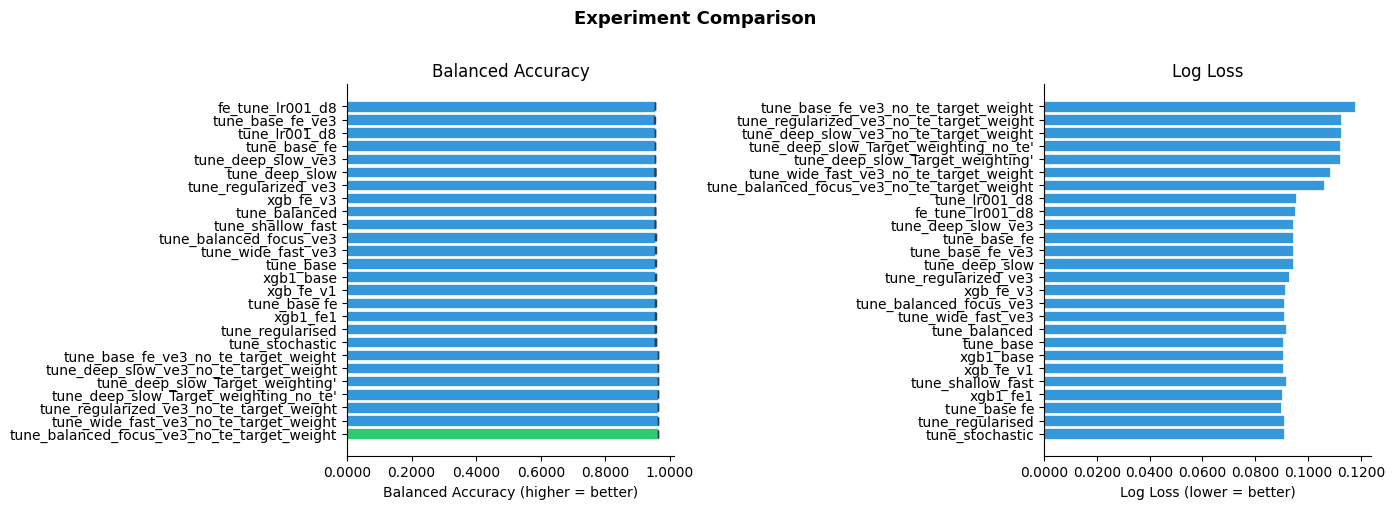

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df_ranked.copy()

for ax, col, label, ascending in [
    (axes[0], 'mean_cv_metric', 'Balanced Accuracy (higher = better)', False),
    (axes[1], 'mean_logloss',   'Log Loss (lower = better)',           True),
]:
    df_s = df_plot.sort_values(col, ascending=ascending)
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_s))]
    ax.barh(df_s['exp_name'], df_s[col], color=colors, edgecolor='white', linewidth=0.5)
    if col == 'mean_cv_metric':
        ax.errorbar(df_s[col], df_s['exp_name'],
                    xerr=df_s['std_cv_metric'],
                    fmt='none', color='#2c3e50', capsize=3, linewidth=1)
    ax.set_xlabel(label)
    ax.set_title(label.split('(')[0].strip())
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Experiment Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3 — Select Experiment to Inspect

In [4]:
# ── Set experiment name here ──────────────────────────────
#EXP_NAME = df_ranked.iloc[0]['exp_name']   # default: best run
EXP_NAME = 'tune_balanced_focus_ve3_no_te_target_weight'               # or set manually
# ─────────────────────────────────────────────────────────

exp_dir = ART_DIR / EXP_NAME
assert exp_dir.exists(), f'Experiment folder not found: {exp_dir}'
print(f'Inspecting: {EXP_NAME}')

Inspecting: tune_balanced_focus_ve3_no_te_target_weight


### 3a — Config Snapshot

In [5]:
config_path = exp_dir / 'config.json'
if config_path.exists():
    config = json.loads(config_path.read_text())
    # Show xgb params as a tidy table
    xgb_params = config.get('xgb', {})
    display(
        pd.DataFrame.from_dict(xgb_params, orient='index', columns=['value'])
        .rename_axis('parameter')
        .style.set_caption(f'XGBConfig — {EXP_NAME}')
    )
else:
    # Fallback to meta.json params
    meta = json.loads((exp_dir / f'{EXP_NAME}_meta.json').read_text())
    display(pd.DataFrame.from_dict(meta['params'], orient='index', columns=['value']))

,value
parameter,
seed,1337
device,cuda
objective,multi:softprob
tree_method,hist
max_depth,6
min_child_weight,4
learning_rate,0.060000
subsample,0.800000
colsample_bytree,0.800000


### 3b — Feature Importance

,feature,importance
0,redshift,2014504.1
1,redshift_log1p,1504918.6
2,g_minus_i,1059239.6
3,g_minus_r_x_r_minus_i,434846.5
4,u_minus_r,347416.2
5,alpha,167579.2
6,g,163747.2
7,i,128380.7
8,r,104465.5
9,u_minus_g,99176.8


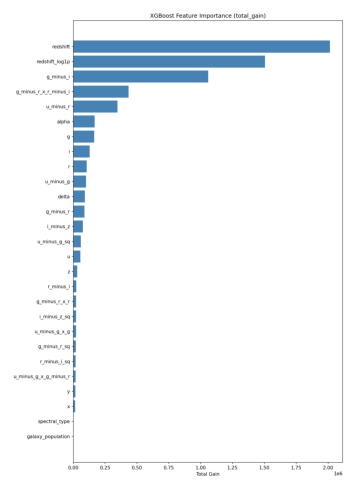

In [6]:
imp_png  = exp_dir / 'feature_importance.png'
imp_parq = exp_dir / 'feature_importance.parquet'


if imp_parq.exists():
    df_imp = pd.read_parquet(imp_parq).sort_values('importance', ascending=False)
    display(df_imp.head(20).style.bar(subset=['importance'], color='#3498db')
            .format({'importance': '{:.1f}'}))

if imp_png.exists():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(mpimg.imread(imp_png))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### 3c — SHAP (if available)

In [ ]:
for fname in ['shap_bar.png', 'shap_beeswarm.png']:
    p = exp_dir / fname
    if p.exists():
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.imshow(mpimg.imread(p))
        ax.axis('off')
        ax.set_title(fname.replace('.png', '').replace('_', ' ').title())
        plt.tight_layout()
        plt.show()
    else:
        print(f'{fname} not available for {EXP_NAME}')

shap_bar.png not available for tune_stochastic
shap_beeswarm.png not available for tune_stochastic


### 3d — OOF Prediction Distribution

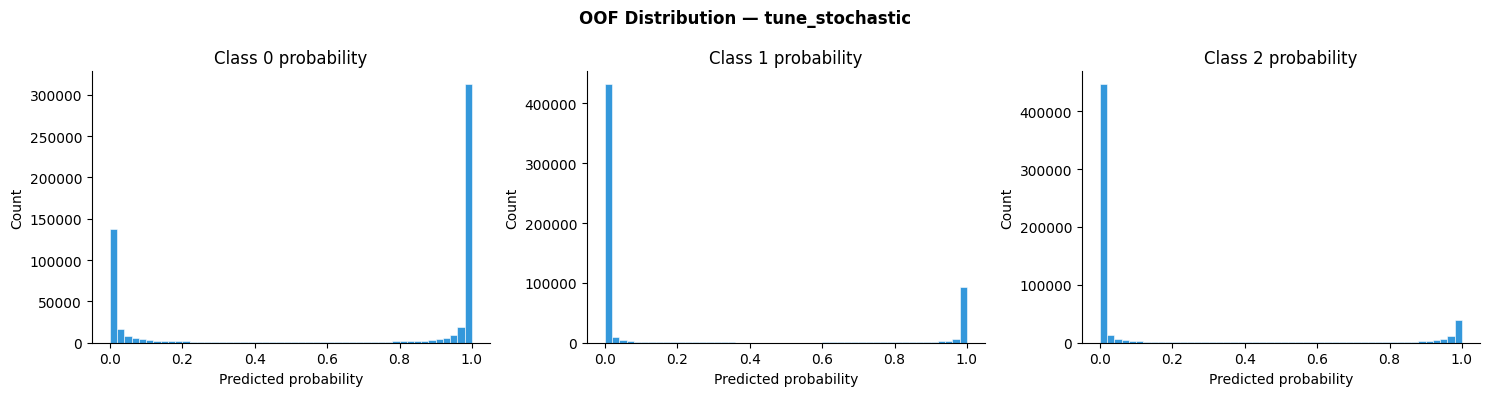

OOF shape: (577347, 3)  |  Mean max prob: 0.9662


In [ ]:
oof_path = exp_dir / f'{EXP_NAME}_oof.npy'
if oof_path.exists():
    oof = np.load(oof_path)
    n_classes = oof.shape[1]
    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 4), sharey=False)
    if n_classes == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.hist(oof[:, i], bins=50, color='#3498db', edgecolor='white', linewidth=0.4)
        ax.set_title(f'Class {i} probability')
        ax.set_xlabel('Predicted probability')
        ax.set_ylabel('Count')
        ax.spines[['top', 'right']].set_visible(False)
    plt.suptitle(f'OOF Distribution — {EXP_NAME}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'OOF shape: {oof.shape}  |  Mean max prob: {oof.max(axis=1).mean():.4f}')
else:
    print('No OOF file found')

## 4 — Side-by-Side Feature Importance (all runs)

In [ ]:
imp_frames = []
for exp in df_log['exp_name']:
    p = ART_DIR / exp / 'feature_importance.parquet'
    if p.exists():
        df_i = pd.read_parquet(p)[['importance']].rename(columns={'importance': exp})
        imp_frames.append(df_i)

if imp_frames:
    df_all_imp = (
        pd.concat(imp_frames, axis=1)
        .assign(mean=lambda d: d.mean(axis=1))
        .sort_values('mean', ascending=False)
        .drop(columns='mean')
    )
    # Reset index so feature names become a plain column — avoids non-unique index issues
    df_display = df_all_imp.head(20).reset_index().rename(columns={'index': 'feature'})

    display(
        df_display.style
        .format({c: '{:.1f}' for c in df_display.columns if c != 'feature'})
        .set_caption('Feature Importance across experiments (top 20 by mean)')
        .hide(axis='index')
    )
else:
    print('No feature_importance.parquet files found')

feature,xgb1_base,xgb1_fe1,tune_lr001_d8,fe_tune_lr001_d8,tune_base,tune_deep_slow,tune_shallow_fast,tune_regularised,tune_stochastic,tune_balanced,tune_base fe,tune_deep_slow,tune_shallow_fast,tune_regularised,tune_stochastic,tune_balanced
0,3628812.5,3492764.8,17923104.0,17266794.0,3628790.5,11111996.0,1391757.4,1989125.6,1346670.4,3640032.2,3492764.8,11111996.0,1391757.4,1989125.6,1346670.4,3640032.2
1,1501084.1,1498703.2,7419305.0,7310950.5,1501077.0,5014277.0,681728.9,1037144.8,716336.0,1761852.9,1498703.2,5014277.0,681728.9,1037144.8,716336.0,1761852.9
2,747157.2,627024.6,3634742.8,3400636.5,747138.2,2683810.8,237944.2,622095.6,677650.1,1026238.6,627024.6,2683810.8,237944.2,622095.6,677650.1,1026238.6
3,455507.1,436824.0,2284826.2,2162574.2,455494.9,1965809.5,220203.2,380283.1,257581.2,662342.1,436824.0,1965809.5,220203.2,380283.1,257581.2,662342.1
4,428374.3,412998.0,1996471.9,1974477.2,428354.4,1489017.4,187635.3,274531.2,219184.3,503463.2,412998.0,1489017.4,187635.3,274531.2,219184.3,503463.2
5,236135.6,216330.7,1062225.5,955982.3,236117.9,1157619.8,131394.3,204384.1,151666.8,381308.1,216330.7,1157619.8,131394.3,204384.1,151666.8,381308.1
6,155888.5,191198.3,687637.2,568086.8,155860.0,894419.6,104088.0,173456.4,147235.4,306281.8,191198.3,894419.6,104088.0,173456.4,147235.4,306281.8
7,127509.5,125016.8,489773.4,564265.1,127508.8,783474.8,79496.4,125065.7,124749.2,226188.2,125016.8,783474.8,79496.4,125065.7,124749.2,226188.2
8,90308.9,110515.5,420929.0,521098.7,90296.5,618265.5,59390.8,122605.2,123802.7,215646.7,110515.5,618265.5,59390.8,122605.2,123802.7,215646.7
9,63197.3,71240.3,274260.7,346752.0,63179.2,508990.0,55829.3,99266.1,98970.9,182076.7,71240.3,508990.0,55829.3,99266.1,98970.9,182076.7
